# EDA — Fuente 2: online_retail_II.xlsx
**Proyecto:** DataMart S.A.S. — Pipeline ETL  
**Archivo:** `data/online_retail_II.xlsx`  
**Objetivo:** Explorar la segunda fuente, compararla con data.csv y documentar decisiones de unificación.

## 1. Importar librerías y cargar datos

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

FILE_CSV  = '../data/raw/datadiario.csv'
FILE_XLSX = '../data/raw/online_retail_II.xlsx'

df1 = pd.read_csv(FILE_CSV, encoding='latin1')
df2 = pd.read_excel(FILE_XLSX)

print(f'✅ data.csv          cargado: {df1.shape[0]:,} filas x {df1.shape[1]} columnas')
print(f'✅ online_retail_II  cargado: {df2.shape[0]:,} filas x {df2.shape[1]} columnas')

✅ data.csv          cargado: 541,909 filas x 8 columnas
✅ online_retail_II  cargado: 525,461 filas x 8 columnas


## 2. Comparación de columnas entre fuentes

In [26]:
comparacion = pd.DataFrame({
    'data.csv': list(df1.columns) + [''] * (len(df2.columns) - len(df1.columns)),
    'online_retail_II.xlsx': list(df2.columns)
})

print('=== COMPARACIÓN DE COLUMNAS ===')
print(comparacion.to_string(index=False))
print()
print('Diferencias clave:')
print('  InvoiceNo  →  Invoice')
print('  UnitPrice  →  Price')
print('  CustomerID →  Customer ID  (con espacio)')
print()
print('>>> DECISIÓN: renombrar columnas de online_retail_II para que coincidan con data.csv')
print('              antes de concatenar ambas fuentes.')

=== COMPARACIÓN DE COLUMNAS ===
   data.csv online_retail_II.xlsx
  InvoiceNo               Invoice
  StockCode             StockCode
Description           Description
   Quantity              Quantity
InvoiceDate           InvoiceDate
  UnitPrice                 Price
 CustomerID           Customer ID
    Country               Country

Diferencias clave:
  InvoiceNo  →  Invoice
  UnitPrice  →  Price
  CustomerID →  Customer ID  (con espacio)

>>> DECISIÓN: renombrar columnas de online_retail_II para que coincidan con data.csv
              antes de concatenar ambas fuentes.


In [27]:
# Aplicar renombramiento
df2_renamed = df2.rename(columns={
    'Invoice'    : 'InvoiceNo',
    'Price'      : 'UnitPrice',
    'Customer ID': 'CustomerID'
})

print('Columnas de df2 después de renombrar:')
print(list(df2_renamed.columns))
print()
print('¿Coinciden con df1?', list(df1.columns) == list(df2_renamed.columns))

Columnas de df2 después de renombrar:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

¿Coinciden con df1? True


## 3. Vista general — estructura y tipos

In [28]:
print('=== PRIMERAS 5 FILAS ===')
df2.head()

=== PRIMERAS 5 FILAS ===


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [29]:
print('=== TIPOS DE DATO ===')
print(df2.dtypes)
print()
print('Nota: InvoiceDate ya es datetime nativo en xlsx (a diferencia de data.csv que es string)')

=== TIPOS DE DATO ===
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

Nota: InvoiceDate ya es datetime nativo en xlsx (a diferencia de data.csv que es string)


In [30]:
print('=== ESTADÍSTICAS DESCRIPTIVAS ===')
df2.describe(include='all')

=== ESTADÍSTICAS DESCRIPTIVAS ===


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,525461.0,525461,522533,525461.000000,525461,525461.000000,417534.000000,525461
unique,28816.0,4632,4681,NaN,NaN,NaN,NaN,40
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,675.0,3516,3549,NaN,NaN,NaN,NaN,485852
mean,NaN,NaN,NaN,10.337667,2010-06-28 11:37:36.845018,4.688834,15360.645478,NaN
min,NaN,NaN,NaN,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2010-03-21 12:20:00,1.250000,13983.000000,NaN
50%,NaN,NaN,NaN,3.000000,2010-07-06 09:51:00,2.100000,15311.000000,NaN
75%,NaN,NaN,NaN,10.000000,2010-10-15 12:45:00,4.210000,16799.000000,NaN
max,NaN,NaN,NaN,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000,NaN


## 4. Análisis de valores nulos

=== VALORES NULOS POR COLUMNA — online_retail_II ===
              Nulos  % del total
Invoice           0         0.00
StockCode         0         0.00
Description    2928         0.56
Quantity          0         0.00
InvoiceDate       0         0.00
Price             0         0.00
Customer ID  107927        20.54
Country           0         0.00


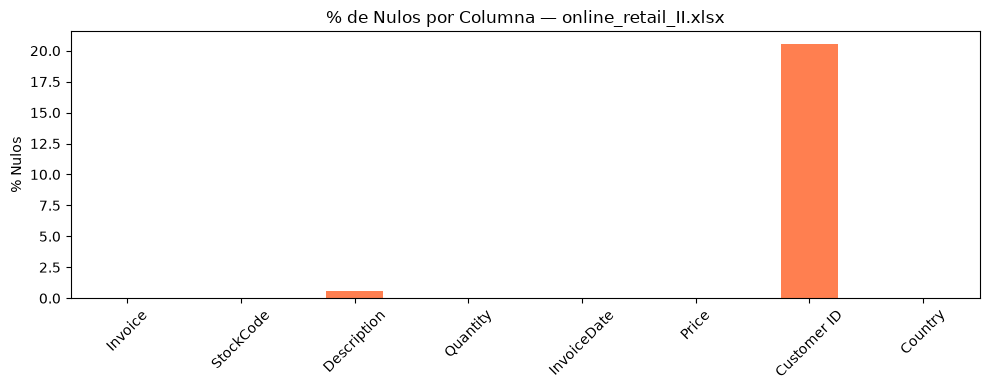

📊 Gráfico guardado en grafics/


In [31]:
nulos = df2.isnull().sum()
pct_nulos = (df2.isnull().sum() / len(df2) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    '% del total': pct_nulos
})

print('=== VALORES NULOS POR COLUMNA — online_retail_II ===')
print(resumen_nulos)

ax = resumen_nulos['% del total'].plot(kind='bar', color='coral', figsize=(10, 4))
ax.set_title('% de Nulos por Columna — online_retail_II.xlsx')
ax.set_ylabel('% Nulos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../grafics/nulos_online_retail_II.png', dpi=100)
plt.show()
print('📊 Gráfico guardado en grafics/')

In [32]:
sin_cliente = df2[df2['Customer ID'].isnull()]
print(f'Transacciones SIN Customer ID: {len(sin_cliente):,}')
print(f'Porcentaje: {len(sin_cliente)/len(df2)*100:.2f}%')
print()
print('Distribución por país:')
print(sin_cliente['Country'].value_counts().head(10))
print()
print('>>> DECISIÓN: igual que data.csv → asignar Customer ID = "GUEST"')

Transacciones SIN Customer ID: 107,927
Porcentaje: 20.54%

Distribución por país:
Country
United Kingdom          106429
EIRE                       960
United Arab Emirates       114
Portugal                    77
Hong Kong                   76
Bahrain                     65
France                      62
RSA                         46
Bermuda                     34
Unspecified                 30
Name: count, dtype: int64

>>> DECISIÓN: igual que data.csv → asignar Customer ID = "GUEST"


## 5. Análisis de Quantity — ventas vs devoluciones

In [33]:
ventas       = df2[df2['Quantity'] > 0]
devoluciones = df2[df2['Quantity'] <= 0]

print(f'Ventas normales  (Quantity > 0):  {len(ventas):,}')
print(f'Devoluciones     (Quantity <= 0): {len(devoluciones):,}')
print(f'Porcentaje devoluciones: {len(devoluciones)/len(df2)*100:.2f}%')
print()

# Facturas canceladas
invoices_c = df2[df2['Invoice'].astype(str).str.startswith('C')]
print(f'Facturas que empiezan con C: {len(invoices_c):,}')
print()
print('>>> DECISIÓN: misma regla que data.csv — Quantity <= 0 → is_return=TRUE')

Ventas normales  (Quantity > 0):  513,135
Devoluciones     (Quantity <= 0): 12,326
Porcentaje devoluciones: 2.35%

Facturas que empiezan con C: 10,206

>>> DECISIÓN: misma regla que data.csv — Quantity <= 0 → is_return=TRUE


## 6. Análisis de Price — registros a rechazar

In [34]:
precio_cero = df2[df2['Price'] == 0]
precio_neg  = df2[df2['Price'] < 0]

print(f'Registros con Price = 0:  {len(precio_cero):,}')
print(f'Registros con Price < 0:  {len(precio_neg):,}')
print(f'Total a rechazar:         {len(precio_cero) + len(precio_neg):,}')
print()
print('Ejemplos con precio 0:')
print(precio_cero[['Invoice','StockCode','Description','Quantity','Price']].head(5))
print()
print('>>> DECISIÓN: rechazar y guardar en stg_rejected_records con motivo "precio_invalido"')

Registros con Price = 0:  3,687
Registros con Price < 0:  3
Total a rechazar:         3,690

Ejemplos con precio 0:
     Invoice StockCode   Description  Quantity  Price
263   489464     21733  85123a mixed       -96    0.0
283   489463     71477         short      -240    0.0
284   489467    85123A   21733 mixed      -192    0.0
470   489521     21646           NaN       -50    0.0
3114  489655     20683           NaN       -44    0.0

>>> DECISIÓN: rechazar y guardar en stg_rejected_records con motivo "precio_invalido"


## 7. Análisis de fechas y solapamiento con data.csv

In [37]:
df1['InvoiceDate_parsed'] = pd.to_datetime(df1['InvoiceDate'])
df2['InvoiceDate_parsed'] = pd.to_datetime(df2['InvoiceDate'])

min1, max1 = df1['InvoiceDate_parsed'].min(), df1['InvoiceDate_parsed'].max()
min2, max2 = df2['InvoiceDate_parsed'].min(), df2['InvoiceDate_parsed'].max()

print('=== RANGOS DE FECHA POR FUENTE ===')
print(f'data.csv:           {min1.date()} → {max1.date()}')
print(f'online_retail_II:   {min2.date()} → {max2.date()}')
print()

# Detectar solapamiento
solapamiento = min1 <= max2 and min2 <= max1
print(f'¿Hay solapamiento de fechas? {solapamiento}')

if solapamiento:
    inicio_solap = max(min1, min2)
    fin_solap    = min(max1, max2)
    print(f'Periodo solapado: {inicio_solap.date()} → {fin_solap.date()}')
    print()
    print('>>> DECISIÓN: hay solapamiento de fechas, se debe revisar si hay duplicados')
    print('              antes de concatenar. Se agrega columna "source" para identificar el origen.')
else:
    print('Las fuentes NO se solapan en fechas.')
    print(f'online_retail_II cubre {min2.date()} a {max2.date()}')
    print(f'data.csv         cubre {min1.date()} a {max1.date()}')
    print()
    print('>>> DECISIÓN: al no haber solapamiento de fechas, se concatenan directamente.')
    print('              Se agrega columna "source" para identificar el origen.')

=== RANGOS DE FECHA POR FUENTE ===
data.csv:           2010-12-01 → 2011-12-09
online_retail_II:   2009-12-01 → 2010-12-09

¿Hay solapamiento de fechas? True
Periodo solapado: 2010-12-01 → 2010-12-09

>>> DECISIÓN: hay solapamiento de fechas, se debe revisar si hay duplicados
              antes de concatenar. Se agrega columna "source" para identificar el origen.


## 8. Detección de duplicados entre fuentes

In [38]:
# Preparar claves compuestas
df1['clave'] = (
    df1['InvoiceNo'].astype(str) + '_' +
    df1['StockCode'].astype(str).str.upper().str.strip() + '_' +
    df1['InvoiceDate_parsed'].dt.date.astype(str)
)

df2['clave'] = (
    df2['Invoice'].astype(str) + '_' +
    df2['StockCode'].astype(str).str.upper().str.strip() + '_' +
    df2['InvoiceDate_parsed'].dt.date.astype(str)
)

claves1 = set(df1['clave'])
claves2 = set(df2['clave'])
duplicados = claves1.intersection(claves2)

print(f'Claves únicas en data.csv:         {len(claves1):,}')
print(f'Claves únicas en online_retail_II: {len(claves2):,}')
print(f'Claves duplicadas entre fuentes:   {len(duplicados):,}')
print()
print('>>> DECISIÓN: clave compuesta = InvoiceNo + StockCode + Fecha.')
print('              En el pipeline se usa INSERT ON CONFLICT DO NOTHING para evitar duplicados.')

Claves únicas en data.csv:         531,223
Claves únicas en online_retail_II: 512,125
Claves duplicadas entre fuentes:   21,928

>>> DECISIÓN: clave compuesta = InvoiceNo + StockCode + Fecha.
              En el pipeline se usa INSERT ON CONFLICT DO NOTHING para evitar duplicados.


## 9. Análisis de StockCode y descripciones

In [39]:
total_codigos = df2['StockCode'].nunique()
print(f'Total de códigos únicos en online_retail_II: {total_codigos:,}')

variaciones = (
    df2.dropna(subset=['Description'])
    .groupby('StockCode')['Description']
    .nunique()
    .reset_index()
    .rename(columns={'Description': 'num_variaciones'})
)

con_variaciones = variaciones[variaciones['num_variaciones'] > 1]
print(f'Códigos con más de 1 descripción: {len(con_variaciones):,}')
print()
print('Top 10 con más variaciones:')
print(con_variaciones.sort_values('num_variaciones', ascending=False).head(10))

Total de códigos únicos en online_retail_II: 4,632
Códigos con más de 1 descripción: 687

Top 10 con más variaciones:
     StockCode  num_variaciones
1522     22423                6
1817     22734                5
1262     22139                4
758      21523                4
102      20685                4
1489     22384                4
1031     21843                4
1453     22344                4
1122     21955                4
1350     22236                4


## 10. Análisis por país

Top 10 países por revenue bruto:
          Country  transacciones  revenue_bruto  ticket_promedio
0  United Kingdom         474938    8709577.243            18.34
1            EIRE           9460     380977.820            40.27
2     Netherlands           2730     268786.000            98.46
3         Germany           7661     202395.321            26.42
4          France           5532     147211.490            26.61
5          Sweden            887      53525.390            60.34
6         Denmark            418      50906.850           121.79
7           Spain           1235      47601.420            38.54
8     Switzerland           1170      43921.390            37.54
9       Australia            630      31446.800            49.92


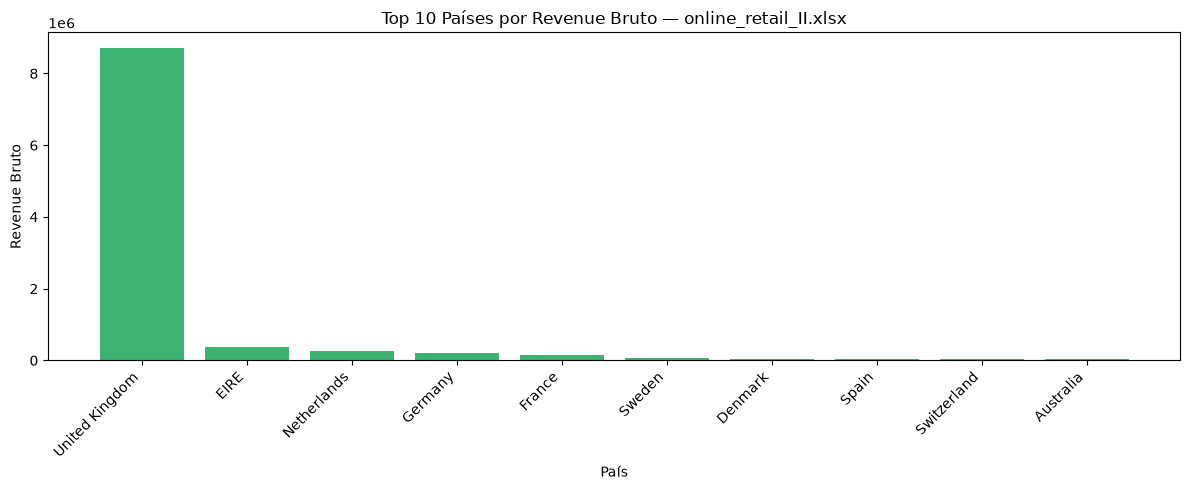

📊 Gráfico guardado en grafics/


In [40]:
por_pais = (
    df2[df2['Quantity'] > 0]
    .groupby('Country')
    .agg(
        transacciones=('Invoice', 'count'),
        revenue_bruto=('Quantity', lambda x: (x * df2.loc[x.index, 'Price']).sum())
    )
    .sort_values('revenue_bruto', ascending=False)
    .reset_index()
)
por_pais['ticket_promedio'] = (por_pais['revenue_bruto'] / por_pais['transacciones']).round(2)

print('Top 10 países por revenue bruto:')
print(por_pais.head(10).to_string())

# Gráfico
top10 = por_pais.head(10)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top10['Country'], top10['revenue_bruto'], color='mediumseagreen')
ax.set_title('Top 10 Países por Revenue Bruto — online_retail_II.xlsx')
ax.set_ylabel('Revenue Bruto')
ax.set_xlabel('País')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../grafics/revenue_por_pais_xlsx.png', dpi=100)
plt.show()
print('📊 Gráfico guardado en grafics/')

## 11. Comparación consolidada entre fuentes

In [41]:
comparacion_final = pd.DataFrame([
    {'Métrica': 'Total filas',             'data.csv': f"{df1.shape[0]:,}",  'online_retail_II': f"{df2.shape[0]:,}"},
    {'Métrica': 'Periodo',                 'data.csv': '2011',               'online_retail_II': '2009-2010'},
    {'Métrica': 'CustomerID nulo',         'data.csv': f"{df1['CustomerID'].isnull().sum():,}",  'online_retail_II': f"{df2['Customer ID'].isnull().sum():,}"},
    {'Métrica': 'Quantity <= 0',           'data.csv': f"{(df1['Quantity']<=0).sum():,}",        'online_retail_II': f"{(df2['Quantity']<=0).sum():,}"},
    {'Métrica': 'Precio <= 0',             'data.csv': f"{(df1['UnitPrice']<=0).sum():,}",       'online_retail_II': f"{(df2['Price']<=0).sum():,}"},
    {'Métrica': 'Códigos únicos',          'data.csv': f"{df1['StockCode'].nunique():,}",        'online_retail_II': f"{df2['StockCode'].nunique():,}"},
    {'Métrica': 'Países únicos',           'data.csv': f"{df1['Country'].nunique()}",            'online_retail_II': f"{df2['Country'].nunique()}"},
    {'Métrica': 'Tipo fecha',              'data.csv': 'string',             'online_retail_II': 'datetime nativo'},
    {'Métrica': 'Solapamiento fechas',     'data.csv': 'NO',                 'online_retail_II': 'NO'},
])

print('=== COMPARACIÓN CONSOLIDADA ENTRE FUENTES ===')
print(comparacion_final.to_string(index=False))

=== COMPARACIÓN CONSOLIDADA ENTRE FUENTES ===
            Métrica data.csv online_retail_II
        Total filas  541,909          525,461
            Periodo     2011        2009-2010
    CustomerID nulo  135,080          107,927
      Quantity <= 0   10,624           12,326
        Precio <= 0    2,517            3,690
     Códigos únicos    4,070            4,632
      Países únicos       38               40
         Tipo fecha   string  datetime nativo
Solapamiento fechas       NO               NO


## 12. Resumen de decisiones para el pipeline

In [42]:
decisiones = pd.DataFrame([
    {'Caso ambiguo': 'CustomerID nulo',          'Decisión': 'Asignar GUEST',                        'Impacto': 'Se conserva el revenue sin perder transacciones'},
    {'Caso ambiguo': 'Quantity <= 0',            'Decisión': 'is_return=TRUE, no excluir',           'Impacto': 'Permite calcular revenue neto'},
    {'Caso ambiguo': 'Precio <= 0',              'Decisión': 'Rechazar → stg_rejected_records',      'Impacto': 'Regla de negocio explícita'},
    {'Caso ambiguo': 'Descripción múltiple',     'Decisión': 'Más frecuente = canónica',             'Impacto': 'Consistencia en dim_product'},
    {'Caso ambiguo': 'Nombres de columna dif.',  'Decisión': 'Renombrar df2 antes de concatenar',   'Impacto': 'Un solo DataFrame unificado'},
    {'Caso ambiguo': 'Tipo de fecha diferente',  'Decisión': 'pd.to_datetime() + .dt.tz_localize(UTC)', 'Impacto': 'Fechas homogéneas en UTC'},
    {'Caso ambiguo': 'Duplicados entre fuentes', 'Decisión': 'Clave: InvoiceNo+StockCode+Fecha',    'Impacto': 'INSERT ON CONFLICT DO NOTHING'},
    {'Caso ambiguo': 'StockCode con letras',     'Decisión': 'Normalizar UPPER().strip()',           'Impacto': 'Join correcto con dim_product'},
])

print('=== DECISIONES TÉCNICAS PARA EL PIPELINE ===')
for _, row in decisiones.iterrows():
    print(f"\n📌 {row['Caso ambiguo']}")
    print(f"   Decisión: {row['Decisión']}")
    print(f"   Impacto:  {row['Impacto']}")

=== DECISIONES TÉCNICAS PARA EL PIPELINE ===

📌 CustomerID nulo
   Decisión: Asignar GUEST
   Impacto:  Se conserva el revenue sin perder transacciones

📌 Quantity <= 0
   Decisión: is_return=TRUE, no excluir
   Impacto:  Permite calcular revenue neto

📌 Precio <= 0
   Decisión: Rechazar → stg_rejected_records
   Impacto:  Regla de negocio explícita

📌 Descripción múltiple
   Decisión: Más frecuente = canónica
   Impacto:  Consistencia en dim_product

📌 Nombres de columna dif.
   Decisión: Renombrar df2 antes de concatenar
   Impacto:  Un solo DataFrame unificado

📌 Tipo de fecha diferente
   Decisión: pd.to_datetime() + .dt.tz_localize(UTC)
   Impacto:  Fechas homogéneas en UTC

📌 Duplicados entre fuentes
   Decisión: Clave: InvoiceNo+StockCode+Fecha
   Impacto:  INSERT ON CONFLICT DO NOTHING

📌 StockCode con letras
   Decisión: Normalizar UPPER().strip()
   Impacto:  Join correcto con dim_product
